In [1]:
netlist = """\
RC Circuit Time Domain
Vin  in  0  SIN(0 $VAMP $FREQ)
R1   in  out  $R
C1   out  0   $C  IC=0
.SAVE v(in) v(out)
.TRAN $TSTEP $TEND  UIC
.END
"""

with open('rc_tran_orig.in', 'w') as f:
    f.write(netlist)

print('rc_tran_orig.in written')


rc_tran_orig.in written


In [2]:
import numpy as np
import ngspice_calc as calc
import matplotlib.pyplot as plt


R      = 1e3       # 1 kΩ
C      = 1e-6      # 1 uF
Vamp   = 1.0       # source amplitude (V)
freq   = 50.0      # source frequency (Hz)


T      = 1.0 / freq
f_c    = 1 / (2 * np.pi * R * C)
w      = 2 * np.pi * freq
phi    = np.degrees(np.arctan(1 / (w * R * C)))


n_cycles = 5
t_end    = n_cycles * T
t_step   = T / 1000

print(f"R      = {R:.0f} Ω")
print(f"C      = {C*1e6:.1f} uF")
print(f"freq   = {freq:.1f} Hz")
print(f"f_c    = {f_c:.2f} Hz")
print(f"T      = {T*1000:.2f} ms")
print(f"Phase shift φ = {phi:.2f} deg")
print(f"Simulating {n_cycles} cycles, t_end = {t_end*1000:.1f} ms")


R      = 1000 Ω
C      = 1.0 uF
freq   = 50.0 Hz
f_c    = 159.15 Hz
T      = 20.00 ms
Phase shift φ = 72.56 deg
Simulating 5 cycles, t_end = 100.0 ms


In [3]:
l = [
    ('$VAMP',  f'{Vamp}'),
    ('$FREQ',  f'{freq}'),
    ('$R',     f'{R}'),
    ('$C',     f'{C:.2e}'),
    ('$TSTEP', f'{t_step:.6e}'),
    ('$TEND',  f'{t_end:.6e}'),
]

calc.replace_strings_1('rc_tran_orig.in', 'rc_tran.in', l)
calc.run_ngspice('rc_tran.in')



No compatibility mode selected!


Circuit: rc circuit time domain

binary raw file "rc_tran.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 3  
Using transient initial conditions

No. of Data Rows : 5014

Total analysis time (seconds) = 0.096

Total elapsed time (seconds) = 0.100 

Total DRAM available = 14741.164 MB.
DRAM currently available = 3253.848 MB.
Maximum ngspice program size =   19.910 MB.
Current ngspice program size =   11.926 MB.

Shared ngspice pages =   10.066 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.965 MB.




'rc_tran.raw'

In [ ]:
s = calc.slv('rc_tran.in')

for i in range(s.num_plots()):
    print(f"  plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")


  plot 0: Transient Analysis | type: tran | vars: ['time', 'v(in)', 'v(out)']


In [ ]:
time = s.get_array('time')
Vin  = s.get_array('v(in)')
VC   = s.get_array('v(out)')
VR   = Vin - VC       

# last 2 cycles only (steady state)
#first few cycles show startup behavior
t_start_ss = (n_cycles - 2) * T
mask  = time >= t_start_ss
t_ss  = time[mask]
VR_ss = VR[mask]
VC_ss = VC[mask]

print(f"Total time points : {len(time)}")
print(f"Steady-state pts  : {len(t_ss)}")
print(f"VR amplitude      : {np.max(VR_ss):.4f} V")
print(f"VC amplitude      : {np.max(VC_ss):.4f} V")


Total time points : 5014
Steady-state pts  : 2001
VR amplitude      : 0.2997 V
VC amplitude      : 0.9540 V


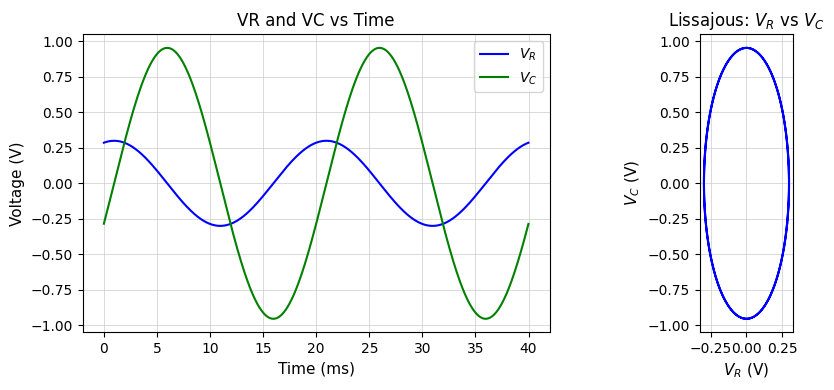

Saved: rc_tran_lissajous.png


In [ ]:
color_VR = 'blue'
color_VC = 'green'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: VR and VC vs time 
t_ms = (t_ss - t_ss[0]) * 1000   # convert to ms, start from 0

ax1.plot(t_ms, VR_ss, color=color_VR, linewidth=1.5, label=r'$V_R$')
ax1.plot(t_ms, VC_ss, color=color_VC, linewidth=1.5, label=r'$V_C$')

ax1.set_xlabel('Time (ms)', fontsize=11)
ax1.set_ylabel('Voltage (V)', fontsize=11)
ax1.set_title('VR and VC vs Time', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

# Plot 2: VR vs VC — Lissajous ellipse 
ax2.plot(VR_ss, VC_ss, color=color_VR, linewidth=1.5)

ax2.set_xlabel(r'$V_R$ (V)', fontsize=11)
ax2.set_ylabel(r'$V_C$ (V)', fontsize=11)
ax2.set_title('Lissajous: $V_R$ vs $V_C$', fontsize=12)
ax2.set_aspect('equal')
ax2.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

plt.tight_layout()
plt.savefig('rc_tran_lissajous.png', dpi=120)
plt.show()

print('Saved: rc_tran_lissajous.png')